## Wasserstein

In [ ]:
DISEASES_DICT = {'respiratory': [ 'COVID-19', 'influenza',], 'neurological': ['Alzheimer disease', 'dementia', 'Parkinson disease',]}
EMBEDDING_DIR = "/media/lleger/LaCie/disease-vector/analogical/"
SAVE_PATH = ""
cell_type_dict = {
                "respiratory": ['CD8-positive, alpha-beta T cell', 'CD4-positive, alpha-beta T cell', 'classical monocyte',
                 'B cell' 'natural killer cell'],
                 
                 "neurological": ['neuron', 'microglial cell', 'oligodendrocyte', 'astrocyte',]
                 }
tissue_type_dict = {
                "respiratory": ["blood"],
                 "neurological": ["brain"]
                 }

import os, sys
sys.path.append("../../")
import warnings; warnings.filterwarnings("ignore")

import json
import scanpy as sc
from tqdm import tqdm
from polygene.model.model import load_trained_model
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

model, tokenizer = load_trained_model("/media/lleger/LaCie/POLYGENE/", checkpoint_n=-1)
diseases = json.load(open(EMBEDDING_DIR + '../diseases.json'))['diseases']

In [2]:
import torch
from polygene.eval.metrics import prepare_cell
probabilities, predictions, labels = ([] for _ in range(3))
cells = sc.concat([sc.read_h5ad(EMBEDDING_DIR + f'{category}_cells.h5ad') for  category in DISEASES_DICT])
for cell in tqdm(cells, "prob"):
    cell_dict = prepare_cell(cell, tokenizer) # gets it in the right ModelInput format
    cell_dict['input_ids'][np.arange(1, 1+len(tokenizer.phenotypic_types))] = 2 # id of mask token
    with torch.no_grad():
        output = model(**{key: val.to(model.device).unsqueeze(0) for key, val in cell_dict.items() if key != 'str_labels'})

    encoder_output = output.logits # tensor shape (B, S, V)
    probabilities.append(encoder_output[:, 1+tokenizer.phenotypic_types.index("disease")])
    labels.append(cell_dict['str_labels'][1:1+len(tokenizer.phenotypic_types)])
    predictions.append([tokenizer.flattened_tokens[output.logits.argmax(dim=-1).squeeze()[1+idx]] for idx in range(len(tokenizer.phenotypic_types))])

probabilities = (torch.cat(probabilities).detach().cpu().numpy(), np.array(predictions), np.array(labels))

prob: 100%|██████████| 3795/3795 [00:49<00:00, 76.60it/s] 


In [5]:
df = pd.DataFrame({'prob': probabilities[0].tolist(), 'y_pred': probabilities[1].tolist()}
                   | {tokenizer.phenotypic_types[idx]:probabilities[2][:, idx] for idx in range(len(tokenizer.phenotypic_types))})
df[['disease', 'cell_type']]= df[['disease', 'cell_type']].applymap(lambda x: ' '.join([word for word in x[1:-1].split('_')]))
df.sample()

,prob,y_pred,assay,cell_type,development_stage,disease,sex,tissue
2096,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[[10x_3_v3], [oligodendrocyte], [86_year_old_h...",[10x_3_v3],oligodendrocyte,[86_year_old_human_stage],normal,[female],[middle_temporal_gyrus]


In [15]:
grouped_df = df.groupby(['disease', 'cell_type']).apply(lambda g: pd.Series({"prob": np.array(g['prob'].tolist()).mean(axis=0),
                                                                           "disease": g['disease'].tolist()[0],
                                                                             "cell_type":g['cell_type'].tolist()[0]})).reset_index(drop=True)
grouped_df.sample()

,prob,disease,cell_type
3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",covid 19,cd8 positive alpha beta t cell


In [16]:
grouped_df.head()


,prob,disease,cell_type
0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",alzheimer disease,microglial cell
1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",alzheimer disease,neuron
2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",covid 19,cd4 positive alpha beta t cell
3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",covid 19,cd8 positive alpha beta t cell
4,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",covid 19,classical monocyte


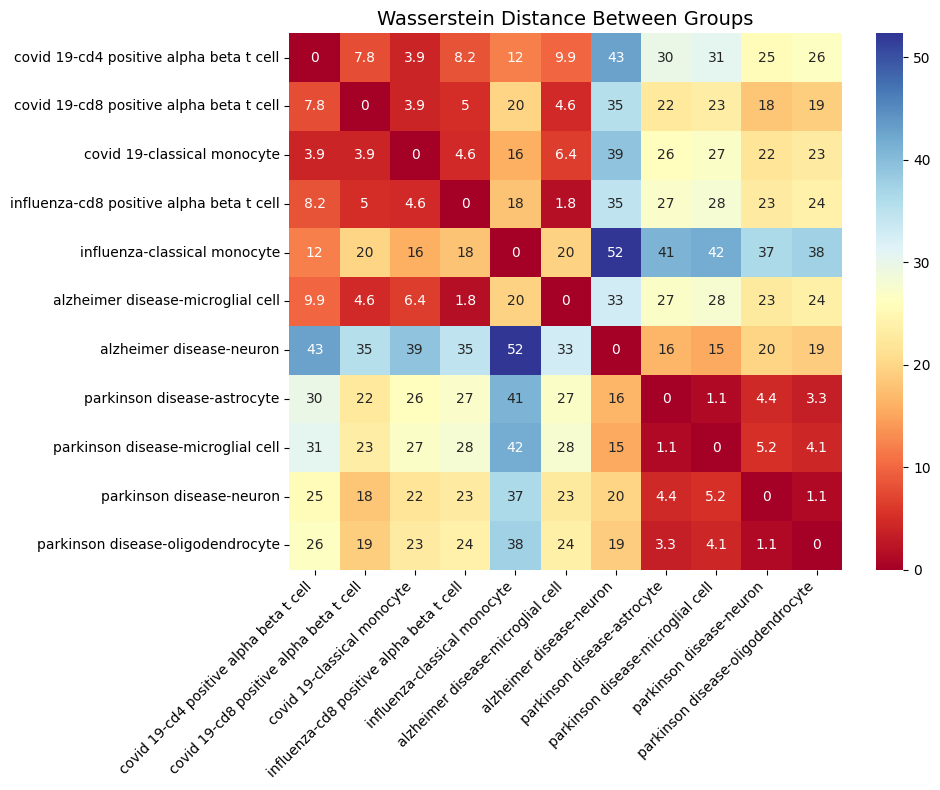

In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance
softmax = lambda x: np.exp(x) / np.exp(x).sum()
df = df[df["disease"] != "normal"]
df = df[df["disease"] != "dementia"]
grouped_df = df.groupby(['disease', 'cell_type']).apply(lambda g: pd.Series({"prob": np.array(g['prob'].tolist()).mean(axis=0),
                                                                           "disease": g['disease'].tolist()[0],
                                                                             "cell_type":g['cell_type'].tolist()[0]})).reset_index(drop=True)
labels = grouped_df[["disease", "cell_type"]].agg("-".join, axis=1)
mat = pd.DataFrame(np.zeros((len(grouped_df), len(grouped_df))), index=labels, columns=labels)
for i in range(len(grouped_df)):
    for j in range(len(grouped_df)):
        p1 = softmax(grouped_df.iloc[i]['prob'])

        p2 = softmax(grouped_df.iloc[j]['prob'])
        positions = np.arange(len(p1))
        mat.iloc[i, j] = wasserstein_distance(positions, positions, p1, p2)

order = [d.lower() for d in sum(DISEASES_DICT.values(), [])]; mat_ordered = mat.loc[[lbl for d in order for lbl in mat.index if lbl.lower().startswith(d[:3])], [lbl for d in order for lbl in mat.columns if lbl.lower().startswith(d[:3])]]  
plt.figure(figsize=(10,8))
sns.heatmap(mat_ordered.round(3), annot=True, cmap="RdYlBu", xticklabels=mat_ordered.index, yticklabels=mat_ordered.columns)
plt.title("Wasserstein Distance Between Groups", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.savefig('Wasserstein_distance.png')
plt.tight_layout()
plt.show()